# Reproducing: "Speeding Up Quantum Annealing with Engineered Dephasing"

This notebook contains an independent, unofficial reproduction of the results presented in the paper *"Speeding Up Quantum Annealing with Engineered Dephasing"*. 

**Credit and Link to Original Paper:**  
[https://quantum-journal.org/papers/q-2025-05-05-1731/](https://quantum-journal.org/papers/q-2025-05-05-1731/)

To run this notebook use provided `enviroment.yml` file, larger simulations can be completed in side scripts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# qutip for quantum simulations
from qutip import sigmax, sigmay, sigmaz, qeye, tensor, basis, sesolve, fidelity

plt.rcParams["font.size"] = 20
_base_fs = plt.rcParams["font.size"]
plt.rcParams["axes.labelsize"] = _base_fs + 3
plt.rcParams["legend.fontsize"] = _base_fs + 3
plt.rcParams["xtick.labelsize"] = _base_fs + 3
plt.rcParams["ytick.labelsize"] = _base_fs + 3
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'stix'

In [2]:
# Define Pauli matrices
sigma_x = sigmax()
sigma_y = sigmay()
sigma_z = sigmaz()
identity = qeye(2)

In [3]:
# Helpers
def landau_zener_hamiltonian(t, v, g):
    return (v * t / 2) * sigma_z + (g / 2) * sigma_x


def qnd_evolution_operator(t_list, v, g, x0):
    """Unitary evolution of LZ under QND dephasing"""
    U_plus, U_minus = [identity], [identity]
    dt = t_list[1] - t_list[0]
    U_p, U_m = identity, identity

    for i in range(1, len(t_list)):
        t = t_list[i]

        H_plus = (1 + x0) * landau_zener_hamiltonian(t, v, g)
        H_minus = (1 - x0) * landau_zener_hamiltonian(t, v, g)

        # Force dense matrix for accurate exponentiation
        U_p = (-1j * H_plus * dt).expm() * U_p
        U_m = (-1j * H_minus * dt).expm() * U_m

        U_plus.append(U_p)
        U_minus.append(U_m)
    return U_plus, U_minus


def coherent_evolution(t_list, v, g):
    """Unitary Evolution of LZ model"""
    U_coherent = [identity]
    dt = t_list[1] - t_list[0]
    U = identity

    for i in range(1, len(t_list)):
        t = t_list[i]
        H = landau_zener_hamiltonian(t, v, g)

        # Force dense matrix for accurate exponentiation
        U = (-1j * H.to("dense") * dt).expm() * U
        U_coherent.append(U)

    return U_coherent


def get_instantaneous_eigenstates(t, v, g):
    H = landau_zener_hamiltonian(t, v, g)
    return H.eigenstates()


def compute_coherence_magnitude(rho):
    return abs(rho[0, 1])

## Figure 1a: Magnitude of Coherences

In [4]:
def transform_to_instantaneous_basis(rho, t, v=1, g=1):
    """density matrix into instantaneous eigenbasis"""
    _, evecs = get_instantaneous_eigenstates(t, v, g)
    P = evecs[0] * evecs[0].dag() + evecs[1] * evecs[1].dag()  # projector
    return P.dag() * rho * P


def compute_qnd_coherence(t_list, rho_initial, v=1, g=1, x0=1):
    """Compute coherence time-series for the QND-like protocol."""
    U_plus_list, U_minus_list = qnd_evolution_operator(t_list, v, g, x0)
    coherence = []

    for i, t in enumerate(t_list):
        U_p = U_plus_list[i]
        U_m = U_minus_list[i]

        rho_plus = U_p * rho_initial * U_p.dag()
        rho_minus = U_m * rho_initial * U_m.dag()

        rho_combined = 0.5 * (rho_plus + rho_minus)
        rho_inst = transform_to_instantaneous_basis(rho_combined, t, v, g)

        coherence.append(compute_coherence_magnitude(rho_inst))
    return np.array(coherence)


def compute_coherent_coherence(t_list, rho_initial, v=1, g=1):
    """Compute coherence time-series for the coherent (no-meter) evolution."""
    U_list = coherent_evolution(t_list, v, g)
    coherence = []

    for i, t in enumerate(t_list):
        U = U_list[i]

        rho = U * rho_initial * U.dag()

        rho_inst = transform_to_instantaneous_basis(rho, t, v, g)

        coherence.append(compute_coherence_magnitude(rho_inst))
    return np.array(coherence)

In [5]:
# Simulation parameters and time array
v, g, x0 = 1, 1, 1
T = 20
t_list = np.linspace(-T / 2 / v, T / 2 / v, 2000)

In [6]:
# Initial state and coherence calculation
psi_plus = (basis(2, 0) + basis(2, 1)).unit()
rho_initial = psi_plus * psi_plus.dag()
coherence_qnd = compute_qnd_coherence(t_list, rho_initial, v=v, g=g, x0=x0)
coherence_coherent = compute_coherent_coherence(t_list, rho_initial, v=v, g=g)

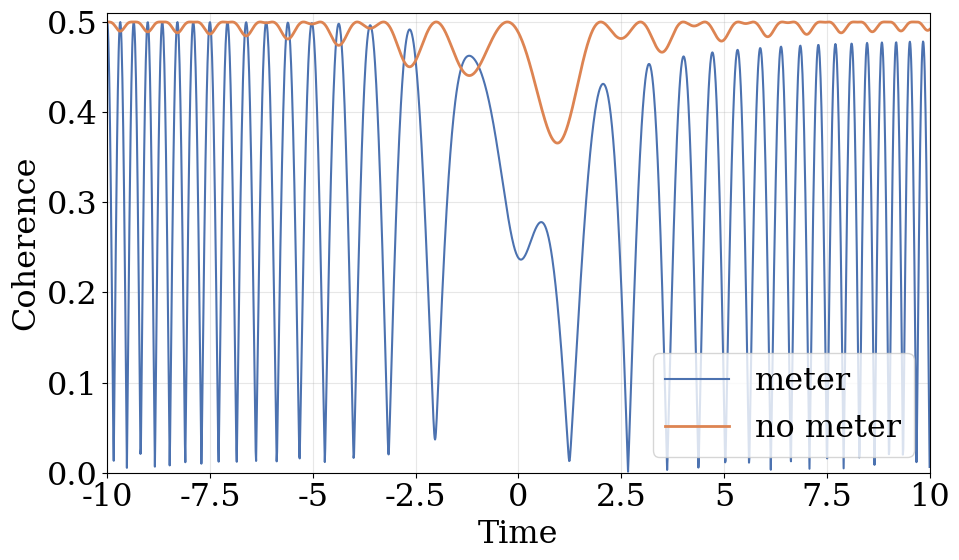

In [7]:
# Plot coherence for QND and coherent protocols
plt.figure(figsize=(10, 6))
plt.plot(t_list, coherence_qnd, linewidth=1.5, label="meter", color="#4c72b0")
plt.plot(t_list, coherence_coherent, linewidth=2, label="no meter", color="#dd8452")

plt.xlabel("Time")
plt.ylabel("Coherence")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.xlim(-10, 10)
plt.ylim(0, 0.51)

ax = plt.gca()
# Format ticks to remove trailing zeros if integer
fmt = FuncFormatter(lambda x, pos: ("%g" % x))
ax.xaxis.set_major_formatter(fmt)

plt.tight_layout()
plt.show()

## Figure 1b: Energy Spectra with Energy Scaling

In [8]:
# Energy spectra and counterdiabatic Hamiltonian functions
def counterdiabatic_hamiltonian(t, v, g):
    # Counterdiabtic term from Kiely
    H_base = landau_zener_hamiltonian(t, v, g)
    cd_term = ((-v * g)) / (2 * ((g**2) + ((v * t) ** 2))) * sigma_y
    return H_base + cd_term


def compute_energy_spectra(t_list, v, g, x0):
    """Create lists of Energy levels for each Hamiltonian type"""
    energies_bare, energies_qnd_plus, energies_qnd_minus, energies_cd = [], [], [], []

    for t in t_list:
        H_bare = landau_zener_hamiltonian(t, v, g)

        evals_bare, _ = H_bare.eigenstates()
        energies_bare.append(evals_bare)

        H_qnd_plus = (1 + x0) * H_bare
        H_qnd_minus = (1 - x0) * H_bare

        evals_plus, _ = H_qnd_plus.eigenstates()
        evals_minus, _ = H_qnd_minus.eigenstates()

        energies_qnd_plus.append(evals_plus)
        energies_qnd_minus.append(evals_minus)

        H_cd = counterdiabatic_hamiltonian(t, v, g)

        evals_cd, _ = H_cd.eigenstates()
        energies_cd.append(evals_cd)
    return (
        np.array(energies_bare),
        np.array(energies_qnd_plus),
        np.array(energies_qnd_minus),
        np.array(energies_cd),
    )

In [9]:
# Parameters and energy spectra for Figure 1b
T, v, g, x0 = 5, 4, 1, 2
t_list_fig1b = np.linspace(-T / 2, T / 2, 1000)
energies_bare, energies_qnd_plus, energies_qnd_minus, energies_cd = (
    compute_energy_spectra(t_list_fig1b, v, g, x0)
)

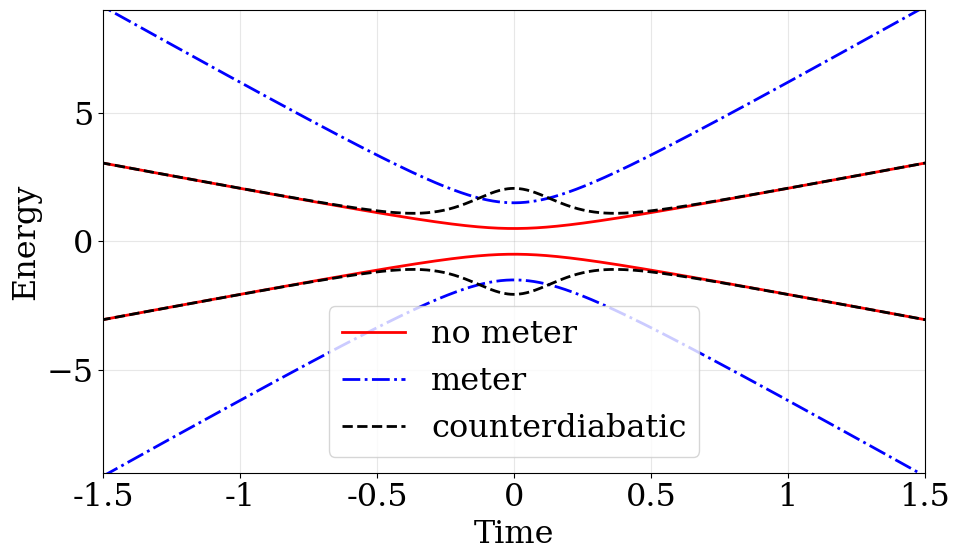

In [10]:
# Plot energy spectra for Figure 1b
plt.figure(figsize=(10, 6))
plt.plot(t_list_fig1b, energies_bare[:, 0], "r-", linewidth=2, label="no meter")
plt.plot(t_list_fig1b, energies_bare[:, 1], "r-", linewidth=2)
plt.plot(t_list_fig1b, energies_qnd_plus[:, 0], "b-.", linewidth=2, label="meter")
plt.plot(t_list_fig1b, energies_qnd_plus[:, 1], "b-.", linewidth=2)
plt.plot(t_list_fig1b, energies_cd[:, 0], "k--", linewidth=2, label="counterdiabatic")
plt.plot(t_list_fig1b, energies_cd[:, 1], "k--", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-1.5, 1.5)
plt.ylim(-9, 9)
ax = plt.gca()
fmt = FuncFormatter(lambda x, pos: ("%g" % x))
ax.xaxis.set_major_formatter(fmt)
plt.tight_layout()
plt.show()

## Figure 2a: Mesh of QND Protocol and Fidelities

> *Note: For full generation of this data using multi-core parallelization, see `OptimizedParallel/Figure2a_optimized.py`.*

In [11]:
def qnd_evolution_states(t_list, v, g, x0, initial_state):
    """
    Evolve under H_plus(t) = (1+x0)*H(t) using sesolve to final state.
    """

    def H_plus_t(t, args):
        return (1.0 + x0) * landau_zener_hamiltonian(t, v, g)

    result = sesolve(H_plus_t, initial_state, t_list)

    return result.states[-1]


def simulate_qnd_protocol_fidelity(T_values, x0_values, g, num_points):
    """
    Calculate fidelity of QND-like protocol for Landau-Zener system for various
    annealing durations T and system-meter interaction strengths x0.
    """
    fidelities = np.zeros((len(T_values), len(x0_values)))
    for i, T in enumerate(T_values):
        v = 20.0 / T
        t_list = np.linspace(-10.0 / v, 10.0 / v, num_points)
        _, eigenstates = get_instantaneous_eigenstates(t_list[-1], v, g)
        target_state = eigenstates[0]  # Ground state at final time

        # Loop over system-meter interaction strengths
        for j, x0 in enumerate(x0_values):
            # Initial state (ground state of initial Hamiltonian)
            _, init_eigenstates = get_instantaneous_eigenstates(t_list[0], v, g)
            initial_state = init_eigenstates[0]  # Ground state at initial time

            # Evolve with sesolve and take final state
            final_state_plus = qnd_evolution_states(t_list, v, g, x0, initial_state)

            fid_val = fidelity(target_state, final_state_plus) ** 2
            fidelities[i, j] = fid_val
    return fidelities

In [12]:
# Parameters for Figure 2a
# T_values = np.linspace(1, 10, 150)
# x0_values = np.linspace(0, 1, 150)
# g = 1.0
# num_points = 1000

# Calculate fidelities for all T and x0
# fidelities = simulate_qnd_protocol_fidelity(T_values, x0_values, g, num_points)

In [13]:
data = np.load("data/Fig2a.npz", allow_pickle=True)

T_values = data["T"]
x0_values = data["x0"]
fidelities = data["fidelities"]
g = data["g"].item()
num_points = data["num_points"].item()

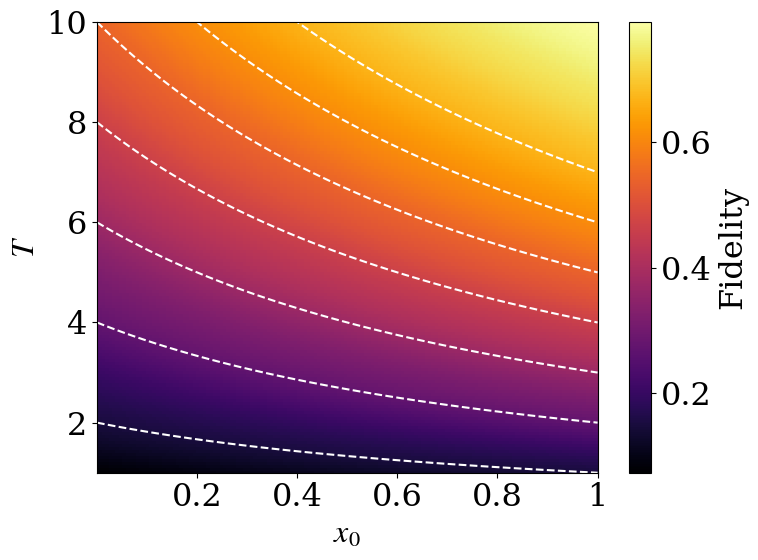

In [14]:
plt.figure(figsize=(8, 6))
X0, T = np.meshgrid(x0_values, T_values)

# heatmap
contour = plt.pcolormesh(X0, T, fidelities, cmap="inferno", shading="auto")
cbar = plt.colorbar(contour)
cbar.set_label("Fidelity")

# dashed lines of constant T(1+x0) to show scaling
for c in [2, 4, 6, 8, 10, 12, 14]:
    x0_line = np.linspace(0, 1, 100)
    t_line = c / (1 + x0_line)
    plt.plot(x0_line, t_line, "w--", linewidth=1.5)

plt.xlabel("$x_0$")
plt.ylabel("$T$")
plt.xlim(0.0001, 1)
plt.ylim(1, 10)
ax = plt.gca()
fmt = FuncFormatter(lambda x, pos: ("%g" % x))
ax.xaxis.set_major_formatter(fmt)
plt.tight_layout()
plt.show()

## Figure 2b: Fidelity along expected optimal scaling path

> *Note: For full generation of this data using multi-core parallelization, see `OptimizedParallel/Figure2b_optimized.py`.*

In [15]:
def ising_parameters(N, seed):
    """Generate random Ising model parameters."""
    np.random.seed(seed)
    J = np.random.uniform(0, 1, size=(N, N))
    h = np.random.uniform(0, 1, size=N)
    return J, h


def ising_hamiltonian(N, J, h):
    """
    Create the nearest-neighbour Ising Hamiltonian for an open chain.
    """
    H = 0
    for i in range(N):
        for j in range(i + 1, N):
            op_list = [identity for _ in range(N)]
            op_list[i] = sigma_z
            op_list[j] = sigma_z
            H += J[i, j] * tensor(op_list)

    # Field terms
    for i in range(N):
        op_list = [identity for _ in range(N)]
        op_list[i] = sigma_z
        H += h[i] * tensor(op_list)

    return H


def transverse_hamiltonian(N):
    """Create the transverse field Hamiltonian for N qubits."""
    H = 0
    for i in range(N):
        op_list = [identity] * N
        op_list[i] = sigma_x
        sx_i = tensor(op_list)
        H += sx_i
    return H


def annealing_hamiltonian(t, T, H_i, H_f):
    """Annealing Hamiltonian w/ schedule f(t) = t/T."""
    s = t / T  # Normalize t to be in [0,1]
    return (1 - s) * H_i + s * H_f


def get_ground_state(H):
    """Get lowest eigenvector"""
    _, evecs = H.eigenstates()
    return evecs[0]

In [16]:
def ising_qnd_final_state_sesolve(
    T, H_initial, H_final, x0, initial_state, num_points=250
):
    """
    Evolve `initial_state` under H_plus(t) = (1+x0)*H(t) using sesolve
    """
    t_list = np.linspace(0, T, num_points)

    # result = sesolve(H_plus_t, initial_state, t_list)
    # meter initial state |0> (eigenstate of sigma_z with eigenvalue +1)
    meter_initial = basis(2, 0)

    # full initial product state (joint Hilbert space)
    psi0 = tensor(initial_state, meter_initial)

    def H_total_t(t, args):
        HS_t = annealing_hamiltonian(t, T, H_initial, H_final)

        # System Hamiltonian: H_S(t) ⊗ I_meter
        H_sys = tensor(HS_t, identity)

        # Interaction: x0 * H_S(t) ⊗ σ_z
        H_int = x0 * tensor(HS_t, sigma_z)

        return H_sys + H_int

    # Evolve and compute fidelity as before
    result = sesolve(H_total_t, psi0, t_list)

    return result.states[-1]


def simulate_ising_qnd_fidelity(T_values, x0_values, N, num_points, num_realizations):
    """
    Calculate fidelity of QND-like protocol for N-qubit Ising model.
    Averages over multiple random Hamiltonian realizations.
    """
    fidelities_accumulated = np.zeros((len(T_values), len(x0_values)))

    # random Hamiltonian realizations
    for realization in range(num_realizations):
        print(f"Processing realization {realization + 1}/{num_realizations}...")

        # random Ising parameters with different seed
        J_matrix, h_vector = ising_parameters(N, seed=realization + 12)

        H_final = ising_hamiltonian(N, J_matrix, h_vector)
        H_initial = transverse_hamiltonian(N)

        # Get ground states
        target_state = get_ground_state(H_final)
        initial_state = get_ground_state(H_initial)

        # Loop annealing durations
        for i, T in enumerate(T_values):
            # Loop system-meter interaction strengths
            for j, x0 in enumerate(x0_values):
                # Simulate final state using sesolve
                final_state = ising_qnd_final_state_sesolve(
                    T, H_initial, H_final, x0, initial_state, num_points=num_points
                )

                rho_sys_final = (final_state * final_state.dag()).ptrace(list(range(N)))
                sys_target_rho = target_state * target_state.dag()

                sqrt_rho = (
                    rho_sys_final.sqrtm() * sys_target_rho * rho_sys_final.sqrtm()
                ).sqrtm()
                fidelity = (sqrt_rho.tr()).real ** 2
                fidelities_accumulated[i, j] += fidelity

    # Average over all realizations
    fidelities = fidelities_accumulated / num_realizations

    return fidelities

In [17]:
# T_values = np.linspace(0, 10, 50)
# x0_values = np.linspace(0, 10, 50)
# N = 3
# num_points = 1000
# num_realizations = 1

# Calculate fidelities for the 3-qubit Ising model
# fidelities = simulate_ising_qnd_fidelity(
#    T_values, x0_values, N, num_points, num_realizations)

In [18]:
data = np.load("data/Fig2b.npz")

T_values = data["T"]
x0_values = data["x0"]
fidelities = data["fidelities"]
N = data["N"].item()
num_points = data["num_points"].item()
num_runs = data["num_runs"].item()

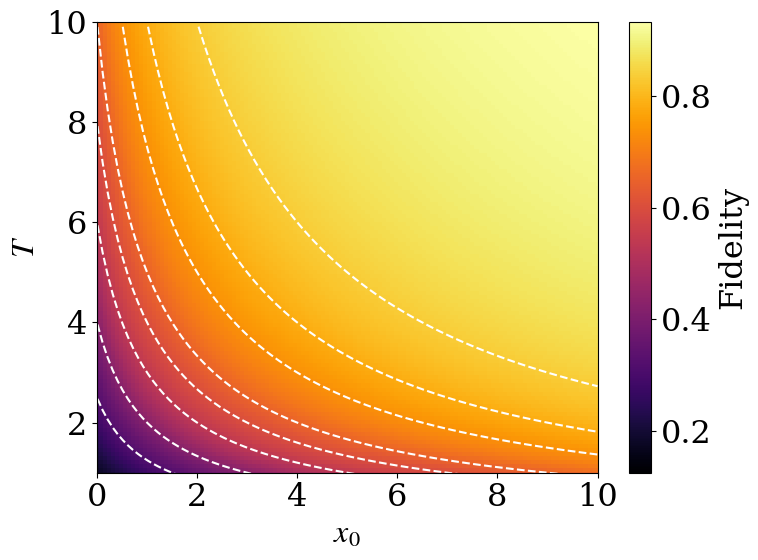

In [19]:
# Fidelity heatmap for Ising model
plt.figure(figsize=(8, 6))
X0, T = np.meshgrid(x0_values, T_values)

contour = plt.pcolormesh(X0, T, fidelities, cmap="inferno", shading="auto")
cbar = plt.colorbar(contour)
cbar.set_label("Fidelity")

# constant T(1+x0) to show scaling
for c in [2.5, 4, 6, 8, 10, 15, 20, 30]:
    x0_line = np.linspace(0.01, 10, 100)
    t_line = c / (1 + x0_line)
    valid_indices = (t_line >= min(T_values)) & (t_line <= max(T_values))
    if np.any(valid_indices):
        plt.plot(x0_line[valid_indices], t_line[valid_indices], "w--", linewidth=1.5)

plt.xlabel("$x_0$")
plt.ylabel("$T$")
plt.xlim(0, 10)
plt.ylim(1, 10)
plt.tight_layout()
plt.show()

## Figure 3: Final Fidelity of QND for Different Values of g

In [20]:
def calculate_infidelity_vs_T(T_values, x0_values, g, num_points):
    """
    Calculate infidelity (1-F) for different annealing times and coupling strengths.
    Uses sesolve to evolve states under H_plus(t) = (1+x0)*H(t).
    """
    results = {}

    for x0 in x0_values:
        infidelities = []

        for T in T_values:
            v = 20.0 / T
            t_list = np.linspace(-10.0 / v, 10.0 / v, num_points)

            # initial and target instantaneous ground states
            _, init_eigenstates = get_instantaneous_eigenstates(t_list[0], v, g)
            initial_state = init_eigenstates[0]
            _, eigenstates = get_instantaneous_eigenstates(t_list[-1], v, g)
            target_state = eigenstates[0]

            # evolve initial_state under H_plus(t) using sesolve and take final state
            def H_plus_t(t, args):
                return (1.0 + x0) * landau_zener_hamiltonian(t, v, g)

            result = sesolve(H_plus_t, initial_state, t_list)
            final_state = result.states[-1]

            # fidelity and infidelity
            fid_val = fidelity(target_state, final_state) ** 2
            infidelity = 1 - fid_val
            infidelities.append(infidelity)

        results[x0] = np.array(infidelities)

    return results


def landau_zener_infidelity(T, g, x0):
    """
    Calculate theoretical Landau-Zener infidelity with time rescaling.
    """
    T_eff = T * (1 + x0)
    v_eff = 20.0 / T_eff
    return np.exp(-np.pi * (g / 2) ** 2 / (v_eff / 2))

In [21]:
T_values = np.logspace(0, 2, 20)  # log scale

num_points = 5000
x0_values = [0, 1, 5, 10]  # System-meter coupling strengths
g = 1.0
markers = ["o", "s", "^", "D"]  # markers x0 values
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# numerical infidelities
results = calculate_infidelity_vs_T(T_values, x0_values, g, num_points)

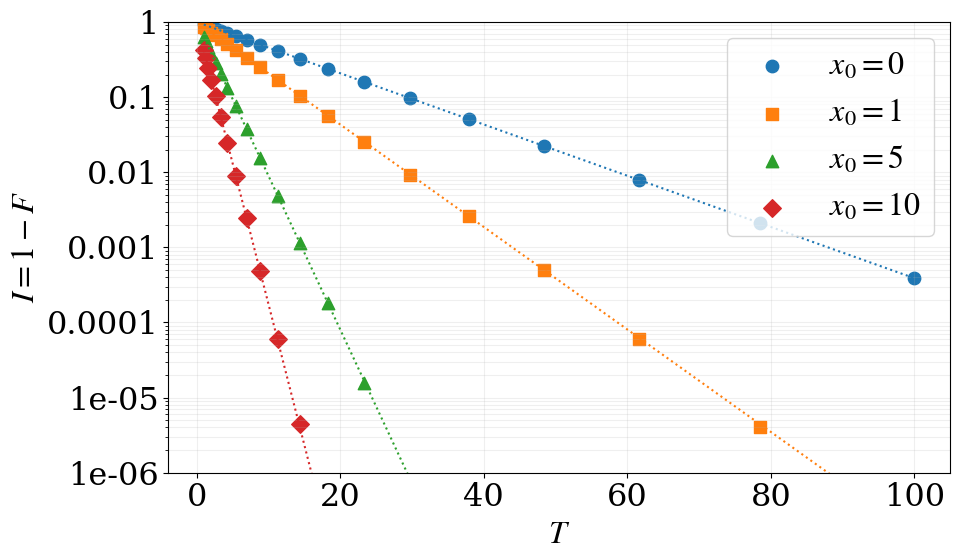

In [22]:
plt.figure(figsize=(10, 6))

# data points and theoretical lines for each x0
for i, x0 in enumerate(x0_values):
    # numerical data points
    plt.scatter(
        T_values,
        results[x0],
        marker=markers[i],
        color=colors[i],
        s=80,
        label=f"$x_0={x0}$",
    )

    # theoretical prediction
    T_theory = np.logspace(0, 2, 100)
    infidelity_theory = [landau_zener_infidelity(t, g, x0) for t in T_theory]
    plt.plot(T_theory, infidelity_theory, color=colors[i], linestyle=":", linewidth=1.5)

plt.yscale("log")
plt.xlabel("$T$")
plt.ylabel("$I = 1-F$")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.ylim(1e-6, 1)
ax = plt.gca()
fmt = FuncFormatter(lambda x, pos: ("%g" % x))
ax.xaxis.set_major_formatter(fmt)
ax.yaxis.set_major_formatter(fmt)
plt.tight_layout()

## Figure 4a: QND vs Coherent Protocol Fidelity Scaling

> *Note: For full generation of this data using multi-core parallelization, see `OptimizedParallel/Figure4a_optimized.py`.*

In [23]:
def calculate_fidelity_with_meter(t_list, v, g, x0, omega):
    """
    Evolve the joint system+meter (two qubits) under
    H(t) = HS(t)⊗I + x0 HS(t)⊗sigma_z + I⊗(omega sigma_x).
    Meter initialised in |0> (sigma_z eigenstate with eigenvalue +1).
    Return fidelity of the reduced system state to the system ground state
    of HS(t_final)
    """
    # system initial and target ground states (kets)
    _, sys_init_evecs = get_instantaneous_eigenstates(t_list[0], v, g)
    sys_initial = sys_init_evecs[0]  # system ground at initial time (ket)
    _, sys_final_evecs = get_instantaneous_eigenstates(t_list[-1], v, g)
    sys_target = sys_final_evecs[0]  # system ground at final time (ket)

    # meter initial state |0> (eigenstate of sigma_z with eigenvalue +1)
    meter_initial = basis(2, 0)

    # full initial product state (joint Hilbert space)
    psi0 = tensor(sys_initial, meter_initial)

    # time-dependent full Hamiltonian on 2-qubit space
    def H_total_t_full(t, args):
        HS_t = landau_zener_hamiltonian(t, v, g)
        term_sys_I = tensor(HS_t, qeye(2))
        term_sys_sigz = x0 * tensor(HS_t, sigma_z)
        term_I_meter = args.get("omega", 0.0) * tensor(qeye(2), sigma_x)
        return term_sys_I + term_sys_sigz + term_I_meter

    # evolve joint state
    result = sesolve(H_total_t_full, psi0, t_list, args={"omega": omega})
    psi_final = result.states[-1]  # joint final ket

    rho_final = psi_final * psi_final.dag()
    rho_sys_final = rho_final.ptrace(list(range(N)))

    # Convert sys_target to a density matrix
    sys_target_rho = sys_target * sys_target.dag()

    # Compute fidelity using the trace of the square root squared definition
    fidelity_trace = fidelity(rho_sys_final, sys_target_rho) ** 2
    return fidelity_trace


def calculate_fidelity_difference_matrix(T_values, omega_values, g, num_points=2500):
    """
    Calculate the fidelity difference matrix for various T and omega values
    using sesolve. Baseline (omega=0) is computed once per T.
    """
    fidelity_diff = np.zeros((len(T_values), len(omega_values)))
    x0 = 1  # Fixed coupling strength

    for i, T in enumerate(T_values):
        v = 20.0 / T
        t_list = np.linspace(-10.0 / v, 10.0 / v, num_points)

        # Baseline fidelity with omega = 0 computed once
        baseline_fidelity = calculate_fidelity_with_meter(t_list, v, g, x0, 0.0)

        # Compute fidelities for each omega; list comprehension keeps code compact
        for j, omega in enumerate(omega_values):
            fidelity = calculate_fidelity_with_meter(t_list, v, g, x0, omega)
            fidelity_diff[i, j] = fidelity - baseline_fidelity

    return fidelity_diff

In [24]:
# T_values = np.linspace(1, 10, 50)
# omega_values = np.linspace(0.0, 10, 50)
# x0 = 1.0
# g = 1.0
# num_points = 1500

# Calculate fidelity differences
# fidelity_diff = calculate_fidelity_difference_matrix(T_values, omega_values, g, num_points)

In [25]:
data = np.load("data/Fig4a.npz")

T_values = data["T"]
omega_values = data["omega"]
fidelity_diff = data["fidelity_diff"]
g = data["g"].item()

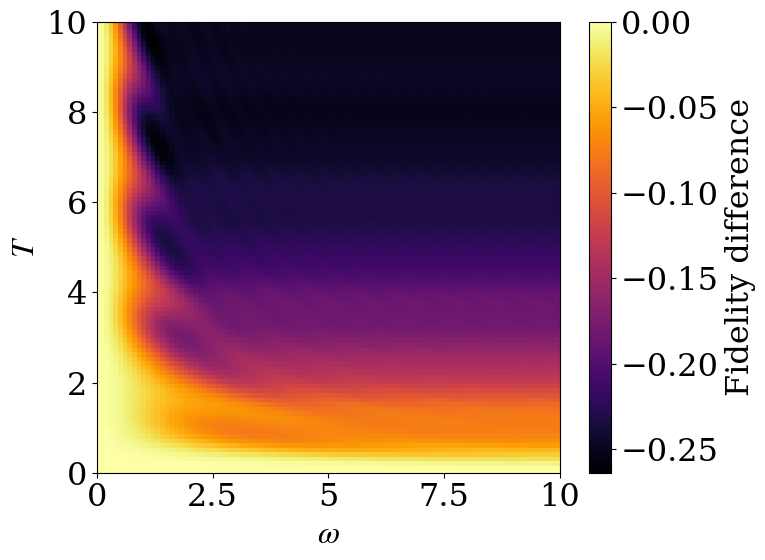

In [26]:
# heatmap of fidelity differences
plt.figure(figsize=(8, 6))
Omega, T = np.meshgrid(omega_values, T_values)
contour = plt.pcolormesh(Omega, T, fidelity_diff, cmap="inferno", shading="auto")
cbar = plt.colorbar(contour)
cbar.set_label("Fidelity difference")

plt.xlabel(r"$\omega$")
plt.ylabel(r"$T$")
plt.xlim(0.0, 10)
plt.ylim(0, 10)
ax = plt.gca()
fmt = FuncFormatter(lambda x, pos: ("%g" % x))
ax.xaxis.set_major_formatter(fmt)
plt.tight_layout()
plt.show()

## Figure 4b: Averaged Fidelity Difference Matrix for Ising Model

> *Note: For full generation of this data using multi-core parallelization, see `OptimizedParallel/Figure4b_optimized.py`.*

In [27]:
def calculate_fidelity_with_meter_ising_explicit(
    t_list, T, H_initial, H_final, x0, omega
):
    """
    Alternative approach: Explicitly track all qubits including meter
    """
    # System ground states
    sys_initial_ground = get_ground_state(H_initial)
    sys_target_ground = get_ground_state(H_final)

    # Get number of system qubits
    N = len(H_initial.dims[0])  # Number of system qubits from dimensions

    # Full initial state: system in ground state, meter in |0⟩
    # The meter is the (N+1)th qubit
    op_list = [sys_initial_ground] + [basis(2, 0)]  # System state + meter state
    psi0 = tensor(op_list)

    def H_total_t(t, args):
        HS_t = annealing_hamiltonian(t, T, H_initial, H_final)
        omega_val = args["omega"]
        x0_val = args["x0"]

        # System Hamiltonian: H_S(t) ⊗ I_meter
        H_sys = tensor(HS_t, qeye(2))

        # Interaction: x0 * H_S(t) ⊗ σ_z
        H_int = x0_val * tensor(HS_t, sigmaz())

        # Meter Hamiltonian: I_system ⊗ (ω σ_x)
        I_sys = tensor([qeye(2)] * N)  # Identity on system qubits
        H_meter = omega_val * tensor(I_sys, sigmax())

        return H_sys + H_int + H_meter

    # Evolve and compute fidelity as before
    result = sesolve(H_total_t, psi0, t_list, args={"omega": omega, "x0": x0})
    psi_final = result.states[-1]

    # Trace out the meter (last qubit)
    rho_final = psi_final * psi_final.dag()
    rho_sys_final = rho_final.ptrace(list(range(N)))

    # Convert sys_target to a density matrix
    sys_target_rho = sys_target_ground * sys_target_ground.dag()

    # Compute fidelity using the trace of the square root squared definition
    fidelity_trace = fidelity(rho_sys_final, sys_target_rho) ** 2
    return fidelity_trace


def calculate_fidelity_difference_matrix_ising_averaged(
    T_values, omega_values, N, num_points, num_realizations
):
    """
    Calculate the fidelity difference matrix for various T and omega values
    for the N-qubit Ising model using sesolve, averaged over multiple random Hamiltonian realizations.
    """
    # Initialize arrays to accumulate results
    fidelity_diff_accumulated = np.zeros((len(T_values), len(omega_values)))
    x0 = 1.0  # Fixed coupling strength

    # Loop over random Hamiltonian realizations
    for realization in range(num_realizations):
        print(f"Processing realization {realization}/{num_realizations}...")

        # Generate random Ising parameters with different seed for each realization
        J_matrix, h_vector = ising_parameters(N, seed=realization + 98)

        # Create Hamiltonians
        H_final = ising_hamiltonian(N, J_matrix, h_vector)
        H_initial = transverse_hamiltonian(N)

        # Loop over annealing durations
        for i, T in enumerate(T_values):
            t_list = np.linspace(0, T, num_points)

            # Baseline fidelity with omega = 0
            baseline_fidelity = calculate_fidelity_with_meter_ising_explicit(
                t_list, T, H_initial, H_final, x0, 0.0
            )

            # Compute fidelities for each omega
            for j, omega in enumerate(omega_values):
                fidelity = calculate_fidelity_with_meter_ising_explicit(
                    t_list, T, H_initial, H_final, x0, omega
                )
                fidelity_diff_accumulated[i, j] += fidelity - baseline_fidelity

    # Average over all realizations
    fidelity_diff = fidelity_diff_accumulated / num_realizations

    return fidelity_diff

In [28]:
# T_values = np.linspace(0.0001, 10, 50)
# omega_values = np.linspace(0, 10, 50)
# N = 3
# x0 = 1.0
# num_points = 1500
# num_realizations = 1

# Calculate averaged fidelity differences for the Ising model
# print("Calculating averaged fidelity differences for Ising model...")
# fidelity_diff_ising_avg = calculate_fidelity_difference_matrix_ising_averaged(T_values, omega_values, N, num_points, num_realizations)

In [29]:
data = np.load("data/Fig4b.npz")

T_values = data["T"]
omega_values = data["omega"]
fidelity_ising_avg = data["fidelity_ising_avg"]
n = data["N"].item()
num_points = data["num_points"].item()
num_runs = data["num_runs"].item()

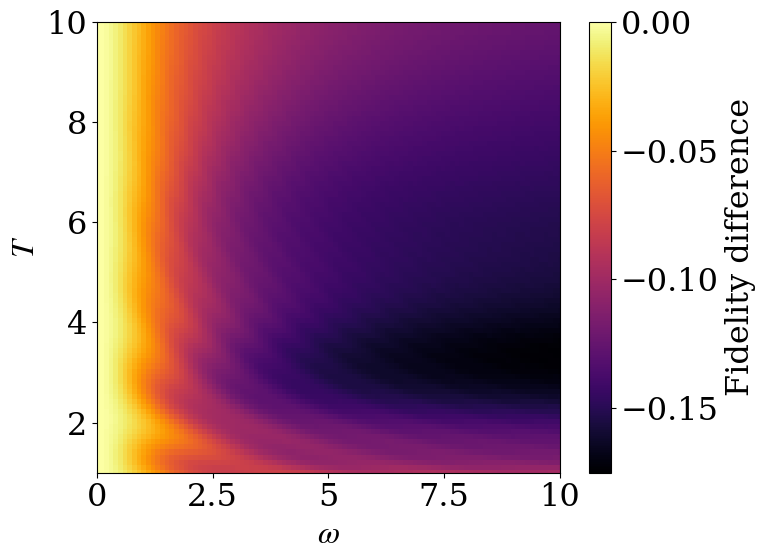

In [30]:
# heatmap of fidelity differences
plt.figure(figsize=(8, 6))
Omega, T = np.meshgrid(omega_values, T_values)
contour = plt.pcolormesh(Omega, T, fidelity_ising_avg, cmap="inferno", shading="auto")
cbar = plt.colorbar(contour)
cbar.set_label("Fidelity difference")

plt.xlabel(r"$\omega$")
plt.ylabel("$T$")
plt.xlim(0.0, 10)
plt.ylim(1, 10)
ax = plt.gca()
fmt = FuncFormatter(lambda x, pos: ("%g" % x))
ax.xaxis.set_major_formatter(fmt)
plt.tight_layout()
plt.show()

## Figure 5a: Time to Solution (TTS) Benchmark

> *Note: For full generation of this data using multi-core parallelization, see `OptimizedParallel/Figure5a_optimized.py`.*

In [31]:
def calculate_success_probability_optimized(
    T, H_i, H_f, x0, sys_initial_ground, sys_target_rho, N
):
    """Optimized calculation for QND protocol"""
    t_eval = [0, T]

    # Pre-calculate operators
    meter_op = identity + x0 * sigma_z
    H_decay = tensor(H_i, meter_op)
    H_rise = tensor(H_f, meter_op)

    # H(t) = (1-t/T)*H_decay + (t/T)*H_rise
    H_list = [[H_decay, "1.0 - t / T"], [H_rise, "t / T"]]

    psi0 = tensor(sys_initial_ground, basis(2, 0))
    args = {"T": T}
    options = {"nsteps": 100000}

    result = sesolve(H_list, psi0, t_eval, args=args, options=options)
    psi_final = result.states[-1]

    rho_final = psi_final.ptrace(list(range(N)))
    fid = fidelity(rho_final, sys_target_rho) ** 2

    return fid

def calculate_success_probability_constrained_optimized(
    T, H_i, H_f, x0, sys_initial_ground, sys_target_rho, N
):
    """Optimized calculation for Constrained protocol.

    The constrained QND-like protocol
    H_int(t) = f(t) * H_f ⊗ X_M  (where X_M = x0 * sigma_z)
    H_total(t) = H_S(t) ⊗ I + f(t) * H_f ⊗ (x0 * sigma_z)
    where H_S(t) = (1-f(t))*H_i + f(t)*H_f and f(t) = t/T
    """
    t_eval = [0, T]

    # System Hamiltonian terms: H_S(t) ⊗ I = (1-t/T)*H_i ⊗ I + (t/T)*H_f ⊗ I
    H_initial_term = tensor(H_i, identity)  # (1-t/T) coefficient
    H_final_term = tensor(H_f, identity)  # (t/T) coefficient

    # Interaction term: f(t) * H_f ⊗ (x0 * sigma_z) = (t/T) * H_f ⊗ (x0 * sigma_z)
    H_interaction = x0 * tensor(H_f, sigma_z)  # (t/T) coefficient

    H_list = [
        [H_initial_term, "1.0 - t / T"],
        [H_final_term, "t / T"],
        [H_interaction, "t / T"],
    ]

    psi0 = tensor(sys_initial_ground, basis(2, 0))
    args = {"T": T}
    nsteps = max(100000, int(200000 * (T / 5.0)))
    options = {"nsteps": nsteps}

    result = sesolve(H_list, psi0, t_eval, args=args, options=options)
    psi_final = result.states[-1]

    sys_rho_final = psi_final.ptrace(list(range(N)))
    fid = fidelity(sys_rho_final, sys_target_rho) ** 2

    return fid

def find_T_for_target_probability(
    H_i, H_f, sys_initial_ground, sys_target_rho, N,
    target_p=0.5, T_guess=5.0, max_iter=10, tol=0.005
):
    """Find annealing time using iterative LZ extrapolation to achieve target probability."""
    T_current = T_guess

    for iteration in range(max_iter):
        # Calculate fidelity with current T at x0=0 (coherent baseline)
        p_current = calculate_success_probability_optimized(
            T_current, H_i, H_f, 0.0, sys_initial_ground, sys_target_rho, N
        )

        # Handle edge cases
        if p_current >= 0.99:
            T_current = T_current * 0.5
            continue
        if p_current <= 0.01:
            T_current = T_current * 2.0
            continue

        # Check convergence
        if abs(p_current - target_p) < tol:
            break

        # LZ extrapolation: T_new = T_current * log(1 - target_p) / log(1 - p_current)
        T_next = T_current * np.log(1 - target_p) / np.log(1 - p_current)
        T_current = max(0.1, T_next)

    return T_current

def calculate_tts_ratio_for_N_single_core(N, n_instances, x0, nT):
    print(f"Computing N={N} with {n_instances} instances...")

    ratios_qnd = []
    ratios_con = []

    for realization in range(n_instances):
        try:
            J_matrix, h_vector = ising_parameters(N, seed=realization)
            H_f = ising_hamiltonian(N, J_matrix, h_vector)
            H_i = transverse_hamiltonian(N)

            # Pre-calculate ground states ONCE per realization
            sys_initial_ground = get_ground_state(H_i)
            sys_target_ground = get_ground_state(H_f)
            sys_target_rho = sys_target_ground * sys_target_ground.dag()

            # Find T_ext using coherent protocol (x0=0)
            # using find_T_for_target_probability defined in cell above or below
            T_ext_coh = find_T_for_target_probability(
                H_i, H_f, sys_initial_ground, sys_target_rho, N, target_p=0.5
            )

            # Generate T values
            T_values = np.logspace(np.log10(0.1 * T_ext_coh), np.log10(10 * T_ext_coh), nT)

            p_qnd = []
            p_coh = []
            p_con = []

            for T in T_values:
                p_qnd.append(
                    calculate_success_probability_optimized(
                        T, H_i, H_f, x0, sys_initial_ground, sys_target_rho, N
                    )
                )
                p_coh.append(
                    calculate_success_probability_optimized(
                        T, H_i, H_f, 0.0, sys_initial_ground, sys_target_rho, N
                    )
                )
                p_con.append(
                    calculate_success_probability_constrained_optimized(
                        T, H_i, H_f, x0, sys_initial_ground, sys_target_rho, N
                    )
                )

            # Calculate TTS
            def get_tts(probs):
                tts_vals = []
                for T, p in zip(T_values, probs):
                    if p >= 0.999:
                        p = 0.999
                    tts = T * np.log(0.05) / np.log(1 - p)
                    tts_vals.append(tts)
                return min(tts_vals)

            tts_qnd = get_tts(p_qnd)
            tts_coh = get_tts(p_coh)
            tts_con = get_tts(p_con)

            ratio_qnd = tts_qnd / tts_coh if tts_coh > 0 else np.nan
            ratio_con = tts_con / tts_coh if tts_coh > 0 else np.nan
            
            if not np.isnan(ratio_qnd):
                ratios_qnd.append(ratio_qnd)
            if not np.isnan(ratio_con):
                ratios_con.append(ratio_con)
            
            if realization % 10 == 0:
                print(f"N={N}: {realization}/{n_instances} done")

        except Exception as e:
            print(f"Error in realization {realization}: {e}")

    avg_qnd = np.mean(ratios_qnd) if ratios_qnd else np.nan
    avg_con = np.mean(ratios_con) if ratios_con else np.nan

    print(f"N={N}: Avg QND={avg_qnd:.4f}, Avg Con={avg_con:.4f}")
    return avg_qnd, avg_con

In [32]:
# N_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
# x0 = 2.0
# n_instances = 100
# nT = 10

# tts_ratios_qnd = []
# tts_ratios_con = []

# for N in N_values:
#     rq, rc = calculate_tts_ratio_for_N_single_core(N, n_instances, x0, nT)
#     tts_ratios_qnd.append(rq)
#     tts_ratios_con.append(rc)

# os.makedirs("output/Paper", exist_ok=True)
# np.savez(
#     "output/Paper/figure_5a_reproduced.npz",
#     N_values=N_values,
#     tts_ratios_qnd=tts_ratios_qnd,
#     tts_ratios_con=tts_ratios_con,
#     x0=x0,
#     n_instances=n_instances,
# )

In [33]:
data = np.load("data/Fig5a.npz")

# Extract expected keys safely (file contains T, omega, fidelity_ising_avg, N, num_points, num_runs)
N_values = data.get("N_values")
tts_ratios_qnd = data.get("tts_ratios_qnd")
tts_ratios_con = data.get("tts_ratios_con")
x0 = data.get("x0")
n_instances = data.get("n_instances")

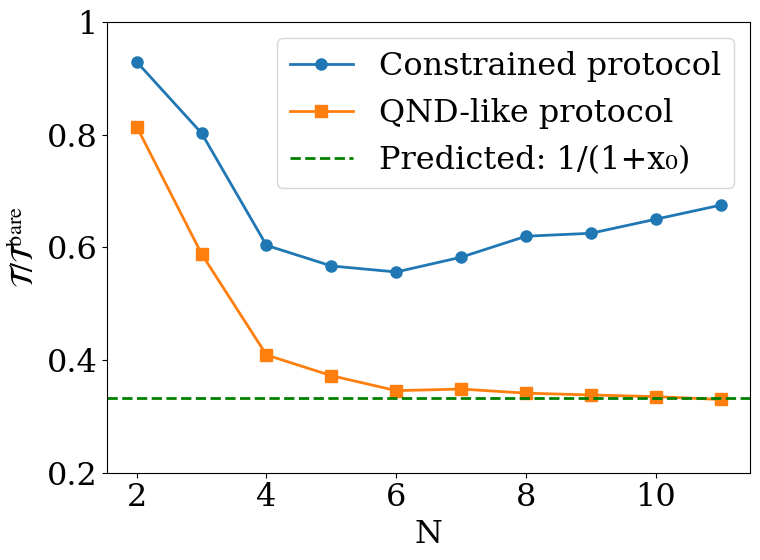

In [34]:
# Plot Figure 5(a)
plt.figure(figsize=(8, 6))
plt.plot(
    N_values,
    tts_ratios_con,
    "o-",
    linewidth=2,
    markersize=8,
    label="Constrained protocol",
)
plt.plot(
    N_values, tts_ratios_qnd, "s-", linewidth=2, markersize=8, label="QND-like protocol"
)
plt.axhline(
    y=1 / (1 + x0),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Predicted: 1/(1+x₀)",
)

plt.xlabel("N")
plt.ylabel(r"$\mathcal{T} / \mathcal{T}^{\mathrm{bare}}$")
plt.ylim([0.2, 1.0])
plt.legend()
ax = plt.gca()
fmt = FuncFormatter(lambda x, pos: ("%g" % x))
ax.yaxis.set_major_formatter(fmt)
plt.tight_layout()

## Figure 5(b-c): Constrained Interaction Strength Response

> *Note: For full generation of this data using multi-core parallelization, see `OptimizedParallel/Figure5bc_optimized.py`.*

In [35]:
def find_T_for_target_probability(
    H_i, H_f, sys_initial_ground, sys_target_rho, N,
    target_p=0.5, T_guess=5.0, max_iter=10, tol=0.005
):
    """Find annealing time using iterative LZ extrapolation to achieve target probability."""
    T_current = T_guess

    for iteration in range(max_iter):
        # Calculate fidelity with current T at x0=0 (coherent baseline)
        p_current = calculate_success_probability_constrained_optimized(
            T_current, H_i, H_f, 0.0, sys_initial_ground, sys_target_rho, N
        )

        # Handle edge cases
        if p_current >= 0.99:
            T_current = T_current * 0.5
            continue
        if p_current <= 0.01:
            T_current = T_current * 2.0
            continue

        # Check convergence
        if abs(p_current - target_p) < tol:
            break

        # LZ extrapolation: T_new = T_current * log(1 - target_p) / log(1 - p_current)
        T_next = T_current * np.log(1 - target_p) / np.log(1 - p_current)
        T_current = max(0.1, T_next)

    return T_current

def calculate_fidelity_vs_x0_single_core(N, x0_values, n_instances):
    print(f"Computing N={N} across {len(x0_values)} x0 values with {n_instances} instances...")
    
    all_fidelities = []
    for realization in range(n_instances):
        try:
            J_matrix, h_vector = ising_parameters(N, seed=realization)
            H_f = ising_hamiltonian(N, J_matrix, h_vector)
            H_i = transverse_hamiltonian(N)

            sys_initial_ground = get_ground_state(H_i)
            sys_target_ground = get_ground_state(H_f)
            sys_target_rho = sys_target_ground * sys_target_ground.dag()

            # Find T_ext for coherent protocol (x0=0)
            T_ext = find_T_for_target_probability(
                H_i, H_f, sys_initial_ground, sys_target_rho, N, target_p=0.5
            )

            fidelities = []
            for x0 in x0_values:
                fid = calculate_success_probability_constrained_optimized(
                    T_ext, H_i, H_f, x0, sys_initial_ground, sys_target_rho, N
                )
                fidelities.append(fid)

            all_fidelities.append(fidelities)
            print(f"N={N}: {realization + 1}/{n_instances} done")
        except Exception as e:
            print(f"Error in realization {realization}: {e}")

    if not all_fidelities:
        return np.zeros(len(x0_values))

    avg_fidelities = np.mean(all_fidelities, axis=0)
    print(f"N={N}: Completed {len(all_fidelities)} instances")
    return avg_fidelities

In [36]:
# x0_values = np.linspace(0, 4, 15)
# n_instances = 100

# N_values_even = [4, 6, 8, 10] # e.g. [2, 4, 6]
# N_values_odd = [3, 5, 7, 9]

# fidelities_even = {}
# for N in N_values_even:
#     fidelities_even[N] = calculate_fidelity_vs_x0_single_core(N, x0_values, n_instances)

# fidelities_odd = {}
# for N in N_values_odd:
#     fidelities_odd[N] = calculate_fidelity_vs_x0_single_core(N, x0_values, n_instances)

# # Create dictionaries to unwrap if necessary, mimicking original output format
# os.makedirs("output/Paper", exist_ok=True)
# np.savez(
#     "output/Paper/figure_5bc_reproduced.npz",
#     x0_values=x0_values,
#     N_values_even=N_values_even,
#     N_values_odd=N_values_odd,
#     fidelities_even=fidelities_even,
#     fidelities_odd=fidelities_odd,
#     n_instances=n_instances,
# )

In [37]:
data = np.load(
    "data/Fig5bc.npz", allow_pickle=True
)

x0_values = data.get("x0_values")
N_values_even = data.get("N_values_even")
N_values_odd = data.get("N_values_odd")
fidelities_even = data.get("fidelities_even")
fidelities_odd = data.get("fidelities_odd")
n_instances = data.get("n_instances")

# unwrap them dicts
fidelities_even = fidelities_even.item()
fidelities_odd = fidelities_odd.item()

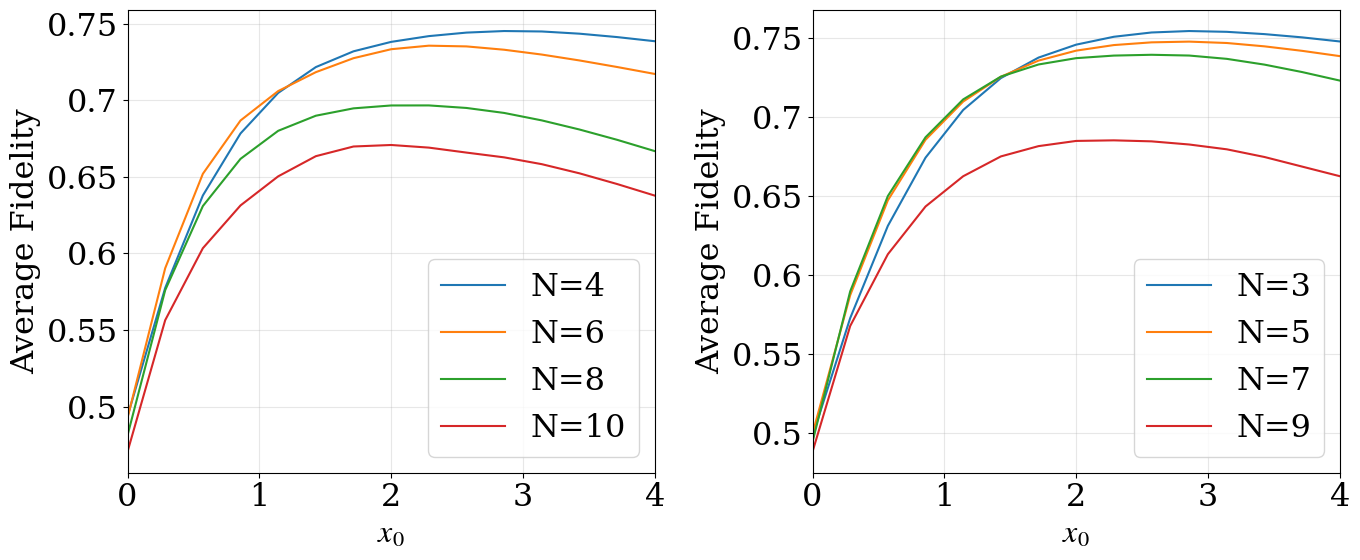

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel (b) - Even qubits (use default color cycle)
for i, N in enumerate(N_values_even):
    key = int(N) if hasattr(N, "item") else N
    ax1.plot(x0_values, fidelities_even[key], label=f"N={key}")

ax1.set_xlabel(r"$x_0$")
ax1.set_ylabel("Average Fidelity")
ax1.grid(alpha=0.3)
ax1.legend()
fmt = FuncFormatter(lambda x, pos: ("%g" % x))
ax1.yaxis.set_major_formatter(fmt)
ax1.set_xlim([0, 4])

# Panel (c) - Odd qubits (use default color cycle)
for i, N in enumerate(N_values_odd):
    key = int(N) if hasattr(N, "item") else N
    ax2.plot(x0_values, fidelities_odd[key], label=f"N={key}")

ax2.set_xlabel(r"$x_0$")
ax2.set_ylabel("Average Fidelity")
ax2.grid(alpha=0.3)
ax2.legend()
ax2.yaxis.set_major_formatter(fmt)
ax2.set_xlim([0, 4])

plt.tight_layout()
plt.show()